In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

In [ ]:
# Load each version separately
df_2020_1 = pd.read_csv("/content/drive/MyDrive/CD/dataset/quality_attributes/2 junit-5/2020-1.csv")
df_2020_4 = pd.read_csv("/content/drive/MyDrive/CD/dataset/quality_attributes/2 junit-5/2020-4.csv")
df_2020_7 = pd.read_csv("/content/drive/MyDrive/CD/dataset/quality_attributes/2 junit-5/2020-7.csv")

# Add version column
df_2020_1["version"] = "2020-1"
df_2020_4["version"] = "2020-4"
df_2020_7["version"] = "2020-7"

Merge Datasets (SAFE MERGE)

In [ ]:
df = pd.concat([df_2020_1, df_2020_4, df_2020_7], ignore_index=True)
print("Merged dataset shape:", df.shape)

Merged dataset shape: (10408, 41)


Identify Qualitative Columns (For Labels ONLY)

In [ ]:
qualitative_cols = df.select_dtypes(include="object").columns
print("Qualitative columns:\n", qualitative_cols)

Qualitative columns:
 Index(['QualifiedName', 'Name', 'Complexity', 'Coupling', 'Size',
       'Lack of Cohesion', 'version'],
      dtype='object')


Create Labels (NO NUMERIC METRICS USED)

In [ ]:
def create_label(row):
    if (
        row["Complexity"] == "low" and
        row["Coupling"] == "low" and
        row["Size"] == "low"
    ):
        return 1   # High Maintainability
    else:
        return 0   # Low Maintainability

df["label"] = df.apply(create_label, axis=1)

In [ ]:
print(df["label"].value_counts(normalize=True))

label
1    0.725596
0    0.274404
Name: proportion, dtype: float64


Select NUMERIC FEATURES ONLY

In [ ]:
FEATURES = [
    "LOC", "MCC", "NBD", "WMC",
    "RFC", "CBO", "LCOM", "ATFD", "NOM"
]

X = df[FEATURES]
y = df["label"]

Handle Missing Values

In [ ]:
X = X.fillna(X.median())

VERSION-AWARE TRAIN / TEST SPLIT

In [ ]:
train_df = df[df["version"].isin(["2020-1", "2020-4"])]
test_df  = df[df["version"] == "2020-7"]

X_train = train_df[FEATURES].fillna(train_df[FEATURES].median())
y_train = train_df["label"]

X_test  = test_df[FEATURES].fillna(train_df[FEATURES].median())
y_test  = test_df["label"]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (8946, 9)
Test size: (1462, 9)


Feature Scaling (FIT ON TRAIN ONLY)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
model_results = []

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

# Train
log_reg.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Logistic Regression Results\n")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression Results

Accuracy: 0.832421340629275
Precision: 0.8447348193697156
Recall: 0.9623467600700525
F1-score: 0.8997134670487106

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.37      0.49       320
           1       0.84      0.96      0.90      1142

    accuracy                           0.83      1462
   macro avg       0.79      0.67      0.70      1462
weighted avg       0.82      0.83      0.81      1462

ROC-AUC: 0.9483253064798599


In [ ]:
model_results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1-score": f1_score(y_test, y_pred_lr),
    "ROC-AUC": roc_auc_score(y_test, y_prob_lr)
})

SVM-RBF

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, roc_auc_score
)

svm_model = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced"
)

# Train
svm_model.fit(X_train_scaled, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("SVM (RBF) Results\n")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

# Store metrics
model_results.append({
    "Model": "SVM (RBF)",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm),
    "Recall": recall_score(y_test, y_pred_svm),
    "F1-score": f1_score(y_test, y_pred_svm),
    "ROC-AUC": roc_auc_score(y_test, y_prob_svm)
})

SVM (RBF) Results

Accuracy: 0.93296853625171
Precision: 0.9924528301886792
Recall: 0.9211908931698775
F1-score: 0.9554950045413261

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.97      0.86       320
           1       0.99      0.92      0.96      1142

    accuracy                           0.93      1462
   macro avg       0.88      0.95      0.91      1462
weighted avg       0.95      0.93      0.94      1462

ROC-AUC: 0.9571913309982487


Train Model (Random Forest)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    max_depth=None
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

Model Evaluation

In [ ]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))
model_results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
})

Accuracy: 0.9281805745554036
Precision: 0.9743824336688015
Recall: 0.9325744308231173
F1-score: 0.9530201342281879
ROC-AUC: 0.9614191112084064

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.91      0.85       320
           1       0.97      0.93      0.95      1142

    accuracy                           0.93      1462
   macro avg       0.88      0.92      0.90      1462
weighted avg       0.93      0.93      0.93      1462



Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, roc_auc_score
)

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

# Train
gb_model.fit(X_train_scaled, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test_scaled)
y_prob_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Gradient Boosting Results\n")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1-score:", f1_score(y_test, y_pred_gb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

# Store metrics
model_results.append({
    "Model": "Gradient Boosting",
    "Accuracy": accuracy_score(y_test, y_pred_gb),
    "Precision": precision_score(y_test, y_pred_gb),
    "Recall": recall_score(y_test, y_pred_gb),
    "F1-score": f1_score(y_test, y_pred_gb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_gb)
})

Gradient Boosting Results

Accuracy: 0.841313269493844
Precision: 0.8421052631578947
Recall: 0.9807355516637478
F1-score: 0.9061488673139159

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.34      0.49       320
           1       0.84      0.98      0.91      1142

    accuracy                           0.84      1462
   macro avg       0.84      0.66      0.70      1462
weighted avg       0.84      0.84      0.81      1462

ROC-AUC: 0.974423982049037


In [ ]:
import pandas as pd

results_df = pd.DataFrame(model_results)
results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
3,Gradient Boosting,0.841313,0.842105,0.980736,0.906149,0.974424
2,Random Forest,0.928181,0.974382,0.932574,0.953020,0.961419
1,SVM (RBF),0.932969,0.992453,0.921191,0.955495,0.957191
0,Logistic Regression,0.832421,0.844735,0.962347,0.899713,0.948325


Why RF was selected?

*   Random Forest was selected because it demonstrated the most balanced performance across accuracy, precision, recall, F1-score, and ROC-AUC, while also providing stable probability estimates and intrinsic feature importance required for maintainability scoring and explainability.

Why other models were not selected?

*   Logistic Regression underperformed due to its linear nature, SVM showed less reliable probability estimates and limited explainability, and Gradient Boosting, although achieving higher ROC-AUC, exhibited lower accuracy and a tendency to over-predict the maintainable class. Therefore, Random Forest was chosen as the most reliable and explainable model for the proposed system.



In [ ]:
# Selecting the final model based on comparative evaluation
best_model = rf_model

In [ ]:
import joblib

# 1. Save model
joblib.dump(best_model, "rf_model.pkl")

# 2. Save scaler
joblib.dump(scaler, "scaler.pkl")

# 3. Save feature list
joblib.dump(FEATURES, "features.pkl")

# 4. Save training stats (for local XAI)
joblib.dump(X_train_stats, "x_train_stats.pkl")

# 5. Save thresholds (for rule-based suggestions)
joblib.dump(THRESHOLDS, "thresholds.pkl")

['thresholds.pkl']

Probability-Based Maintainability Score

In [ ]:
def maintainability_score(sample_row):
    """
    sample_row: dictionary or single row (before scaling)
    """
    sample_df = pd.DataFrame([sample_row])
    sample_scaled = scaler.transform(sample_df)
    prob = best_model.predict_proba(sample_scaled)[0][1]
    return round(prob * 100, 2)

Feature Importance

In [ ]:
importance = pd.Series(
    best_model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

print(importance)

CBO     0.659439
LOC     0.107814
RFC     0.056006
WMC     0.053915
MCC     0.053105
NBD     0.036369
NOM     0.020204
LCOM    0.011357
ATFD    0.001793
dtype: float64


GLOBAL XAI (WHY THE MODEL THINKS LIKE THIS)

Global Feature Importance:

CBO     0.659439
LOC     0.107814
RFC     0.056006
WMC     0.053915
MCC     0.053105
NBD     0.036369
NOM     0.020204
LCOM    0.011357
ATFD    0.001793
dtype: float64


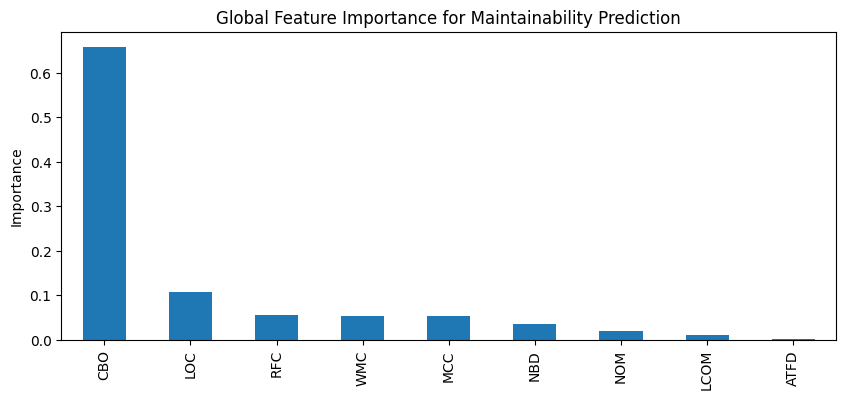

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Global feature importance
importance = pd.Series(
    best_model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

print("Global Feature Importance:\n")
print(importance)

# Optional visualization
importance.plot(kind="bar", figsize=(10,4))
plt.title("Global Feature Importance for Maintainability Prediction")
plt.ylabel("Importance")
plt.show()

LOCAL XAI (WHY THIS CODE GOT THIS SCORE)

Compute training statistics (ONCE)

In [ ]:
X_train_stats = {
    feature: {
        "mean": X_train[feature].mean(),
        "std": X_train[feature].std()
    }
    for feature in FEATURES
}

Contribution analysis function

In [ ]:
def compute_local_contributions(sample):
    contributions = []

    for feature in FEATURES:
        mean = X_train_stats[feature]["mean"]
        std  = X_train_stats[feature]["std"]

        z = (sample[feature] - mean) / std

        if abs(z) < 0.75:
            continue  # ignore weak effects

        strength = "slightly" if abs(z) < 1.5 else "significantly"
        direction = "reduced" if z > 0 else "improved"

        contributions.append({
            "feature": feature,
            "z_score": z,
            "strength": strength,
            "direction": direction
        })

    return contributions

SEMANTIC XAI (HUMAN-LIKE EXPLANATION)

In [ ]:
METRIC_EXPLANATIONS = {
    "MCC": {
        "name": "Cyclomatic Complexity",
        "meaning": "the number of independent execution paths",
        "impact": "higher values increase cognitive load and testing effort",
        "maintainability_effect": "harder to understand, modify, and debug"
    },
    "CBO": {
        "name": "Coupling Between Objects",
        "meaning": "the degree of dependency on external modules",
        "impact": "high coupling propagates changes across the system",
        "maintainability_effect": "changes become risky and error-prone"
    },
    "LOC": {
        "name": "Lines of Code",
        "meaning": "the physical size of the code",
        "impact": "larger code units are harder to read and maintain",
        "maintainability_effect": "increases effort for comprehension and refactoring"
    },
    "NBD": {
        "name": "Nested Block Depth",
        "meaning": "depth of nested control structures",
        "impact": "deep nesting reduces readability",
        "maintainability_effect": "logic becomes difficult to follow"
    },
    "LCOM": {
        "name": "Lack of Cohesion",
        "meaning": "how unrelated class members are",
        "impact": "low cohesion indicates scattered responsibilities",
        "maintainability_effect": "harder to evolve and refactor"
    }
}

In [ ]:
def compute_semantic_evidence(sample, X_train_stats, importance):
    evidence = []

    for feature, meta in METRIC_EXPLANATIONS.items():
        mean = X_train_stats[feature]["mean"]
        std  = X_train_stats[feature]["std"]

        z = (sample[feature] - mean) / std

        if abs(z) < 0.75:
            continue  # ignore weak signals

        evidence.append({
            "feature": feature,
            "z": z,
            "importance": importance[feature]
        })

    return evidence

Convert evidence → semantic explanation

In [ ]:
def semantic_xai_explanation(evidence):
    explanations = []

    for e in evidence:
        meta = METRIC_EXPLANATIONS[e["feature"]]

        deviation = (
            "significantly higher than normal"
            if e["z"] > 1.5 else
            "moderately higher than normal"
            if e["z"] > 0 else
            "lower than normal"
        )

        influence = (
            "strongly reduced"
            if e["z"] > 1 else
            "reduced"
            if e["z"] > 0 else
            "improved"
        )

        explanation = (
            f"{meta['name']} is {deviation}. "
            f"This reflects {meta['meaning']}. "
            f"As a result, {meta['impact']}, which makes the code "
            f"{meta['maintainability_effect']}. "
            f"Therefore, this factor {influence} the maintainability score."
        )

        explanations.append(explanation)

    return explanations

RULE-BASED SUGGESTIONS (WHAT TO FIX)

Data-driven thresholds

In [ ]:
THRESHOLDS = {
    feature: X_train[feature].quantile(0.75)
    for feature in FEATURES
}

Suggestion Engine

In [ ]:
def generate_suggestions(sample):
    suggestions = []

    if sample["LOC"] > THRESHOLDS["LOC"]:
        suggestions.append("Split large methods into smaller functions.")

    if sample["MCC"] > THRESHOLDS["MCC"]:
        suggestions.append("Reduce conditional complexity to simplify control flow.")

    if sample["NBD"] > THRESHOLDS["NBD"]:
        suggestions.append("Reduce nesting depth for better readability.")

    if sample["CBO"] > THRESHOLDS["CBO"]:
        suggestions.append("Minimize external dependencies to reduce coupling.")

    if sample["LCOM"] > THRESHOLDS["LCOM"]:
        suggestions.append("Improve cohesion by grouping related responsibilities.")

    return suggestions

In [ ]:
def analyze_code(sample_dict):
    # Convert input to DataFrame
    sample_df = pd.DataFrame([sample_dict])
    sample_scaled = scaler.transform(sample_df)

    # =========================
    # 1. Maintainability Score
    # =========================
    prob = best_model.predict_proba(sample_scaled)[0][1]
    score = round(prob * 100, 2)

    # =========================
    # 2. Semantic XAI (WHY)
    # =========================
    evidence = compute_semantic_evidence(
        sample_dict,
        X_train_stats,
        importance
    )
    why = semantic_xai_explanation(evidence)

    # =========================
    # 3. Rule-Based Suggestions (WHAT TO FIX)
    # =========================
    fixes = generate_suggestions(sample_dict)

    return score, why, fixes